In [3]:
# Core PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Dataset & utilities
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt
import numpy as np

# Device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [4]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # Standard weights and bias
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Learnable gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # Converting the scores to gates between 0 and 1 using sigmoid activation function
        gates = torch.sigmoid(self.gate_scores)

        # Applying pruning (element-wise multiplication)
        pruned_weights = self.weight * gates

        # Performing linear operation
        return F.linear(x, pruned_weights, self.bias)

layer = PrunableLinear(5, 3)

x = torch.randn(2, 5)   # batch size = 2, input features = 5
output = layer(x)

print("Output shape:", output.shape)

Output shape: torch.Size([2, 3])


In [5]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        # flattening the image to 1d (important!)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x
model = PrunableNet()

x = torch.randn(4, 3, 32, 32)
output = model(x)

print("Output shape:", output.shape)

Output shape: torch.Size([4, 10])


In [6]:
# Transform: convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor()
])

# Loading the training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Loading the testing dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Creating the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 170M/170M [00:07<00:00, 23.9MB/s]


Train size: 50000
Test size: 10000


In [7]:
model = PrunableNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
# Sparsity Loss Function
def compute_sparsity_loss(model):
    loss = 0.0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()

    return loss


# Hyperparameter for sparsity
lambda_sparse = 1e-3

# Training Loop
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Classification loss
        ce_loss = criterion(outputs, labels)

        # Sparsity loss
        sparsity_loss = compute_sparsity_loss(model)

        # Total loss
        loss = ce_loss + lambda_sparse * sparsity_loss

        # Backward pass
        loss.backward()

        # Update parameters
        optimizer.step()

        total_loss += loss.item()

    print(f"Sparsity loss: {sparsity_loss.item():.2f}")

print(f"CE: {ce_loss.item():.4f}, Sparsity: {sparsity_loss.item():.2f}")

Sparsity loss: 6058.12
Sparsity loss: 4547.65
Sparsity loss: 3465.80
Sparsity loss: 2684.57
Sparsity loss: 2116.20
CE: 1.4323, Sparsity: 2116.20


In [9]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [10]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    zero = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            zero += (gates < threshold).sum().item()

    return 100 * zero / total

In [16]:
test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.2f}%")
sparsity = calculate_sparsity(model)
print(f"Sparsity: {sparsity:.2f}%")

Test Accuracy: 44.28%
Sparsity: 98.10%


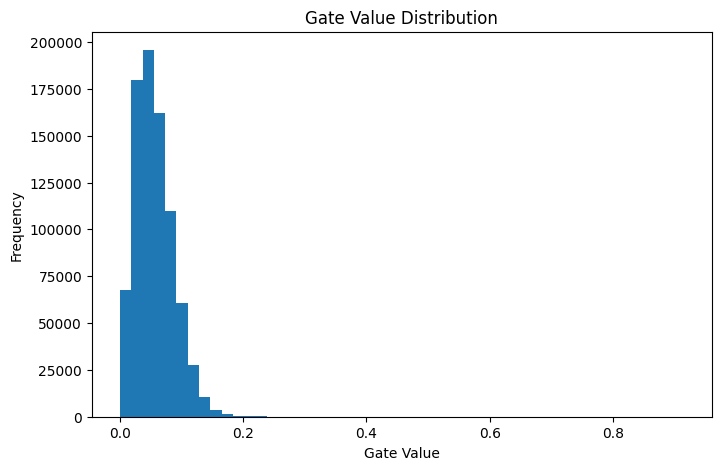

In [12]:
all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
        all_gates.extend(gates.flatten())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")

plt.savefig("gate_distribution1e5.png")  # saves file
plt.show()